# 🏠 Data Analysis Project — London Housing Dataset
**Dataset:** `LondonHousingData.csv` — Monthly housing prices, sales volume & crime data across 45 London areas (1995–2019)  
**Goal:** Work with datetime data, engineer year/month features, and answer real analytical questions about housing prices and crime trends  
**Tools:** Pandas · Matplotlib · Seaborn

> **Commands used in this project:**  
> `pd.read_csv` · `count()` · `isnull().sum()` · `sns.heatmap()` · `dtypes` · `pd.to_datetime()` · `.dt.year` · `.dt.month` · `insert()` · `drop()` · `groupby()` · filtering


## 1. Imports

In [39]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [40]:
# Load the London Housing dataset
data = pd.read_csv('LondonHousingData.csv')

## 3. First Look at the Data

In [41]:
# First 5 rows — understand structure and column types
data.head()

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN
2,3/1/1995,city of london,79121,E09000001,14.0,NaN
3,4/1/1995,city of london,77101,E09000001,7.0,NaN
4,5/1/1995,city of london,84409,E09000001,10.0,NaN


In [42]:
# Last 5 rows — confirm data loaded correctly
data.tail()

,date,area,average_price,code,houses_sold,no_of_crimes
13544,9/1/2019,england,249942,E92000001,64605.0,NaN
13545,10/1/2019,england,249376,E92000001,68677.0,NaN
13546,11/1/2019,england,248515,E92000001,67814.0,NaN
13547,12/1/2019,england,250410,E92000001,NaN,NaN
13548,1/1/2020,england,247355,E92000001,NaN,NaN


## 4. Data Structure & Info

In [43]:
# Number of rows and columns
print("Shape:", data.shape)

Shape: (13549, 6)


In [44]:
# Data type of each column — note 'date' is still a string (object) at this point
data.dtypes

date                 str
area                 str
average_price      int64
code                 str
houses_sold      float64
no_of_crimes     float64
dtype: object

In [45]:
# Non-null counts and memory usage
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  str    
 1   area           13549 non-null  str    
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  str    
 4   houses_sold    13455 non-null  float64
 5   no_of_crimes   7439 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 635.2 KB


## 5. Missing Values Check

In [46]:
# count() shows non-null count per column
print("Non-null count per column:")
print(data.count())

Non-null count per column:
date             13549
area             13549
average_price    13549
code             13549
houses_sold      13455
no_of_crimes      7439
dtype: int64


In [47]:
# isnull().sum() shows missing count per column
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
date                0
area                0
average_price       0
code                0
houses_sold        94
no_of_crimes     6110
dtype: int64


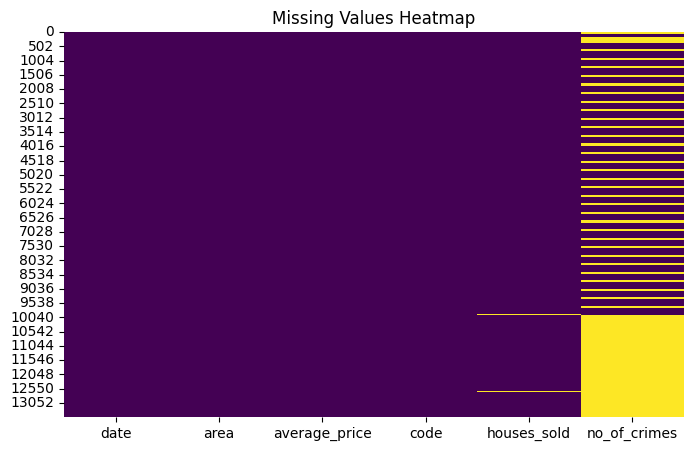

In [48]:
# Heatmap visualization of missing values
# White streaks reveal exactly where and how much data is missing
plt.figure(figsize=(8, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [49]:
# Note: 'no_of_crimes' is missing for ~6,110 rows — likely because crime data
# collection started later than price data (price data goes back to 1995).
# We'll keep these as NaN since dropping them would remove a large historical chunk.
print(f"no_of_crimes missing: {data['no_of_crimes'].isnull().sum()} out of {len(data)} rows")

no_of_crimes missing: 6110 out of 13549 rows


## 6. Descriptive Statistics

In [50]:
# Statistical summary of numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
average_price,13549.0,263519.684331,187617.504910,40722.0,132380.0,222919.0,336843.0,1463378.0
houses_sold,13455.0,3893.994129,12114.402476,2.0,247.0,371.0,3146.0,132163.0
no_of_crimes,7439.0,2158.352063,902.087742,0.0,1623.0,2132.0,2582.0,7461.0


---
## 📋 Analytical Questions
---

### Q1 — Convert the 'date' column to Date-Time format

> **Task:** The `date` column is currently stored as text. Convert it using `pd.to_datetime()`
> so we can extract year/month and do proper time-based analysis.


In [51]:
# Before conversion
print("Before:", data['date'].dtype)

# Convert to datetime
data['date'] = pd.to_datetime(data['date'])

# After conversion
print("After: ", data['date'].dtype)
data.head()

Before: str
After:  datetime64[us]


,date,area,average_price,code,houses_sold,no_of_crimes
0,1995-01-01,city of london,91449,E09000001,17.0,NaN
1,1995-02-01,city of london,82203,E09000001,7.0,NaN
2,1995-03-01,city of london,79121,E09000001,14.0,NaN
3,1995-04-01,city of london,77101,E09000001,7.0,NaN
4,1995-05-01,city of london,84409,E09000001,10.0,NaN


### Q2 — Add 'year' column, and 'month' column as the 2nd column

> **Task:**  
> (A) Add a `year` column extracted from `date`  
> (B) Add a `month` column extracted from `date`, inserted at **position 2** (right after `date`)


In [52]:
# Q2-A: Extract year using .dt.year and add as a new column
data['year'] = data['date'].dt.year
data.head()

,date,area,average_price,code,houses_sold,no_of_crimes,year
0,1995-01-01,city of london,91449,E09000001,17.0,NaN,1995
1,1995-02-01,city of london,82203,E09000001,7.0,NaN,1995
2,1995-03-01,city of london,79121,E09000001,14.0,NaN,1995
3,1995-04-01,city of london,77101,E09000001,7.0,NaN,1995
4,1995-05-01,city of london,84409,E09000001,10.0,NaN,1995


In [53]:
# Q2-B: Extract month, then insert it at index 1 (i.e. the 2nd column, right after 'date')
month_values = data['date'].dt.month
data.insert(1, 'month', month_values)

data.head()

,date,month,area,average_price,code,houses_sold,no_of_crimes,year
0,1995-01-01,1,city of london,91449,E09000001,17.0,NaN,1995
1,1995-02-01,2,city of london,82203,E09000001,7.0,NaN,1995
2,1995-03-01,3,city of london,79121,E09000001,14.0,NaN,1995
3,1995-04-01,4,city of london,77101,E09000001,7.0,NaN,1995
4,1995-05-01,5,city of london,84409,E09000001,10.0,NaN,1995


In [54]:
# Confirm column order
print("Column order:", data.columns.tolist())

Column order: ['date', 'month', 'area', 'average_price', 'code', 'houses_sold', 'no_of_crimes', 'year']


### Q3 — Remove the 'year' and 'month' columns

> **Task:** Drop the columns we just created using `drop()` with `axis=1`.

> 💡 **Why create them just to drop them?**  
> This mirrors a common real-world workflow: engineer features to verify the extraction logic
> works correctly, then remove them once confirmed (or keep them only if needed downstream).
> Here we drop them as instructed, but the dataset now has datetime properly parsed,
> so year/month can always be re-extracted on demand from `data['date']`.


In [55]:
# Drop both columns permanently using inplace=True
data.drop(['year', 'month'], axis=1, inplace=True)

print("Columns after drop:", data.columns.tolist())

Columns after drop: ['date', 'area', 'average_price', 'code', 'houses_sold', 'no_of_crimes']


### Q4 — Show all records where 'No. of Crimes' is 0, and count them

> **Task:** Filter the dataset for rows where `no_of_crimes` equals exactly 0.


In [56]:
# Filter for zero-crime records
zero_crime = data[data['no_of_crimes'] == 0]

print(f"Number of records with 0 crimes: {len(zero_crime)}")
zero_crime.head(10)

Number of records with 0 crimes: 104


,date,area,average_price,code,houses_sold,no_of_crimes
72,2001-01-01,city of london,284262,E09000001,24.0,0.0
73,2001-02-01,city of london,198137,E09000001,37.0,0.0
74,2001-03-01,city of london,189033,E09000001,44.0,0.0
75,2001-04-01,city of london,205494,E09000001,38.0,0.0
76,2001-05-01,city of london,223459,E09000001,30.0,0.0
77,2001-06-01,city of london,242435,E09000001,36.0,0.0
78,2001-07-01,city of london,230700,E09000001,40.0,0.0
79,2001-08-01,city of london,231632,E09000001,30.0,0.0
80,2001-09-01,city of london,229806,E09000001,30.0,0.0
81,2001-10-01,city of london,263887,E09000001,26.0,0.0


In [57]:
# Which areas have the most zero-crime months?
zero_crime['area'].value_counts().head(10)

area
city of london    104
Name: count, dtype: int64

### Q5 — Maximum & Minimum 'average_price' per year in England

> **Task:** Filter for `area == 'england'`, group by year, and find the max/min average price per year.


In [58]:
# Re-extract year temporarily for this analysis (since we dropped it in Q3)
data['year'] = data['date'].dt.year

# Filter for England only
england = data[data['area'] == 'england']

print(f"England records: {len(england)}")
england.head()

England records: 301


,date,area,average_price,code,houses_sold,no_of_crimes,year
13248,1995-01-01,england,53203,E92000001,47639.0,NaN,1995
13249,1995-02-01,england,53096,E92000001,47880.0,NaN,1995
13250,1995-03-01,england,53201,E92000001,67025.0,NaN,1995
13251,1995-04-01,england,53591,E92000001,56925.0,NaN,1995
13252,1995-05-01,england,53678,E92000001,64192.0,NaN,1995


In [59]:
# Group by year, find max and min average_price per year
price_per_year = england.groupby('year')['average_price'].agg(['max', 'min'])
price_per_year

,max,min
year,,
1995,53901,52788
1996,55755,52333
1997,61564,55789
1998,65743,61659
1999,75071,65522
2000,84191,75219
2001,95992,84245
2002,119982,96215
2003,138985,121610


In [60]:
# Overall maximum and minimum average_price ever recorded in England
print(f"Overall MAX average_price in England: £{england['average_price'].max():,}")
print(f"Overall MIN average_price in England: £{england['average_price'].min():,}")

Overall MAX average_price in England: £250,410
Overall MIN average_price in England: £52,333


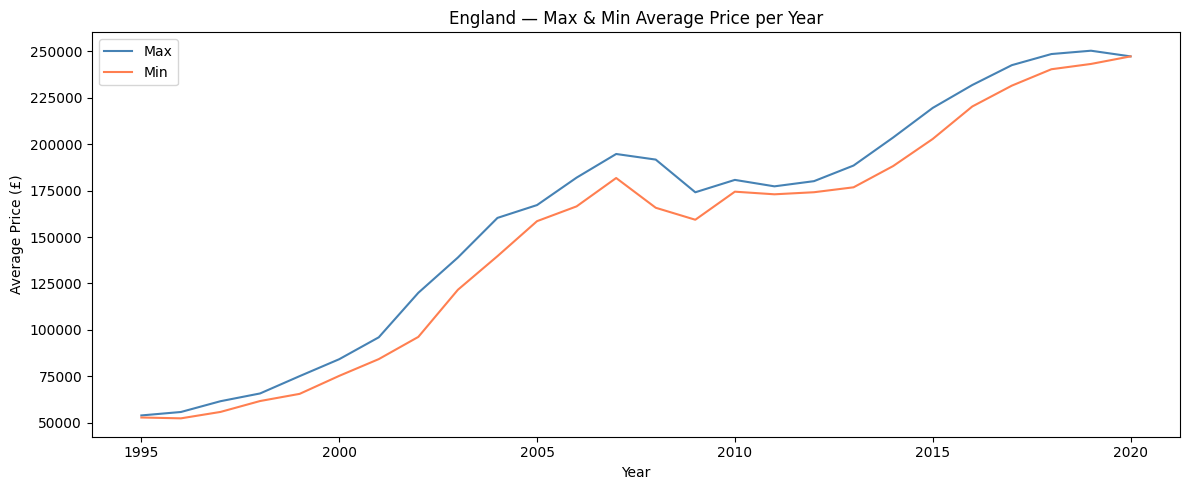

In [61]:
# Visualize the trend of average price over the years
plt.figure(figsize=(12, 5))
plt.plot(price_per_year.index, price_per_year['max'], label='Max', color='steelblue')
plt.plot(price_per_year.index, price_per_year['min'], label='Min', color='coral')
plt.title("England — Max & Min Average Price per Year")
plt.xlabel("Year")
plt.ylabel("Average Price (£)")
plt.legend()
plt.tight_layout()
plt.show()

### Q6 — Maximum & Minimum No. of Crimes recorded per area

> **Task:** Group by area, find max and min `no_of_crimes` for each.


In [62]:
# Group by area and aggregate max/min no_of_crimes
crimes_per_area = data.groupby('area')['no_of_crimes'].agg(['max', 'min'])
crimes_per_area

,max,min
area,,
barking and dagenham,2049.0,1217.0
barnet,2893.0,1703.0
bexley,1914.0,860.0
brent,2937.0,1850.0
bromley,2637.0,1441.0
camden,4558.0,2079.0
city of london,10.0,0.0
croydon,3263.0,2031.0
ealing,3401.0,1871.0


In [63]:
# Top 10 areas by maximum crimes recorded in a single month
crimes_per_area.sort_values('max', ascending=False).head(10)

,max,min
area,,
westminster,7461.0,3504.0
lambeth,4701.0,2381.0
camden,4558.0,2079.0
southwark,3821.0,2267.0
newham,3668.0,2130.0
hackney,3466.0,1870.0
ealing,3401.0,1871.0
islington,3384.0,1871.0
tower hamlets,3316.0,1646.0


### Q7 — Count of records per area where average_price < 100,000

> **Task:** Filter for `average_price < 100000`, then count how many records exist per area.


In [64]:
# Filter for affordable housing records
affordable = data[data['average_price'] < 100000]

print(f"Total affordable records: {len(affordable)}")

# Count of these records per area
affordable_counts = affordable['area'].value_counts()
affordable_counts

Total affordable records: 2209


area
north east              112
north west              111
yorks and the humber    110
east midlands            96
west midlands            94
england                  87
barking and dagenham     85
south west               78
east of england          76
newham                   72
bexley                   64
waltham forest           64
lewisham                 62
havering                 60
greenwich                59
south east               59
croydon                  57
enfield                  54
sutton                   54
hackney                  53
redbridge                52
southwark                48
tower hamlets            47
outer london             46
hillingdon               44
hounslow                 41
lambeth                  41
brent                    40
london                   39
merton                   35
bromley                  33
haringey                 33
ealing                   31
inner london             31
harrow                   30
kingston upon t

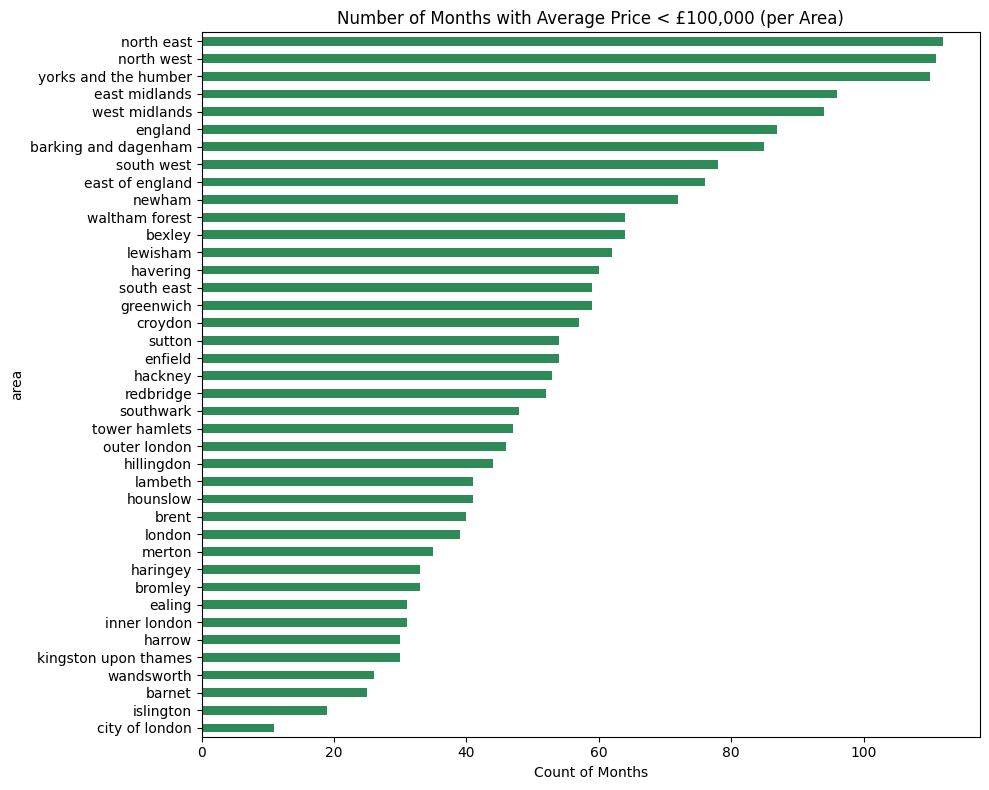

In [65]:
# Visualize areas with the most months under £100,000
plt.figure(figsize=(10, 8))
affordable_counts.sort_values().plot(kind='barh', color='seagreen')
plt.title("Number of Months with Average Price < £100,000 (per Area)")
plt.xlabel("Count of Months")
plt.tight_layout()
plt.show()

## 7. Visualizations

### 7.1 Univariate — Numerical Variables

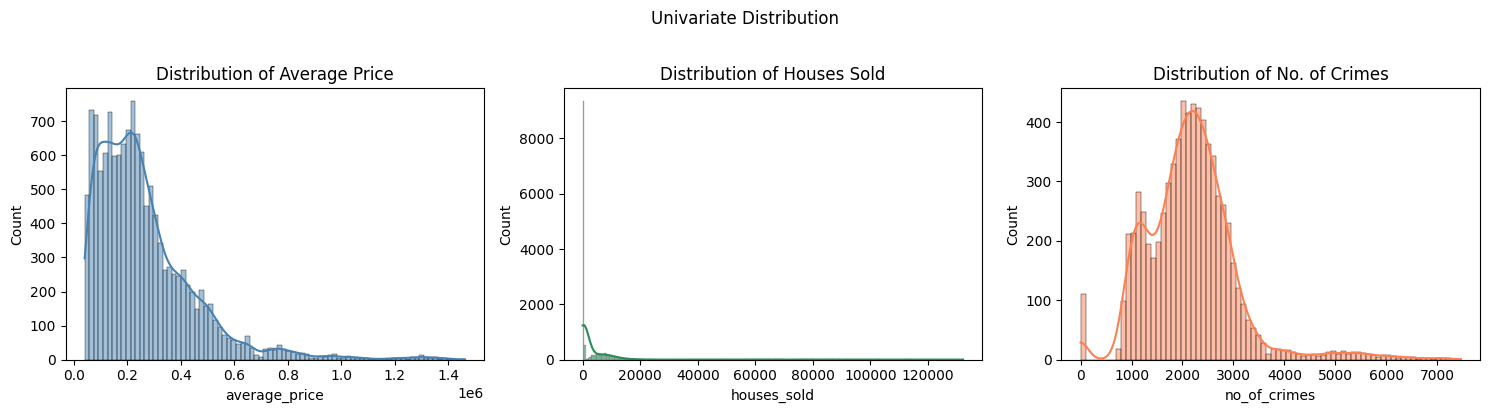

In [66]:
# Distribution of average_price, houses_sold, and no_of_crimes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data['average_price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Average Price')

sns.histplot(data['houses_sold'].dropna(), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Houses Sold')

sns.histplot(data['no_of_crimes'].dropna(), kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribution of No. of Crimes')

plt.suptitle("Univariate Distribution", y=1.02)
plt.tight_layout()
plt.show()

In [67]:
# Skewness check
print("Skewness:")
print(data[['average_price', 'houses_sold', 'no_of_crimes']].skew().round(2))

Skewness:
average_price    1.99
houses_sold      6.27
no_of_crimes     1.29
dtype: float64


### 7.2 Time Series — Price Trend Over Time

<function matplotlib.pyplot.show(close=None, block=None)>

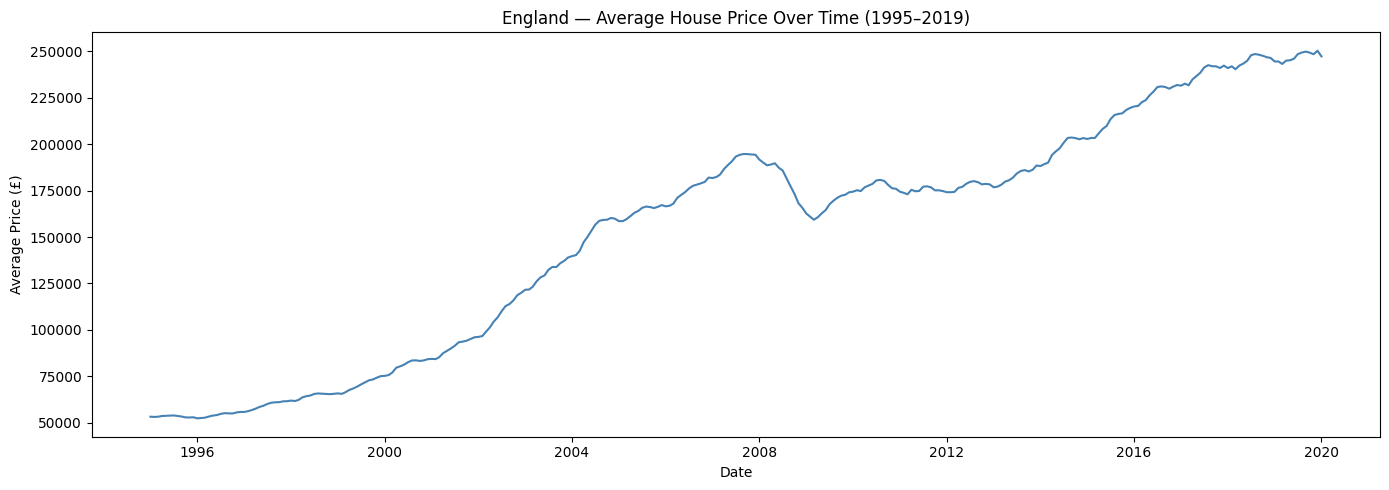

In [68]:
# Average price trend for England over the full time range
england_trend = data[data['area'] == 'england'].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(england_trend['date'], england_trend['average_price'], color='steelblue')
plt.title("England — Average House Price Over Time (1995–2019)")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.show

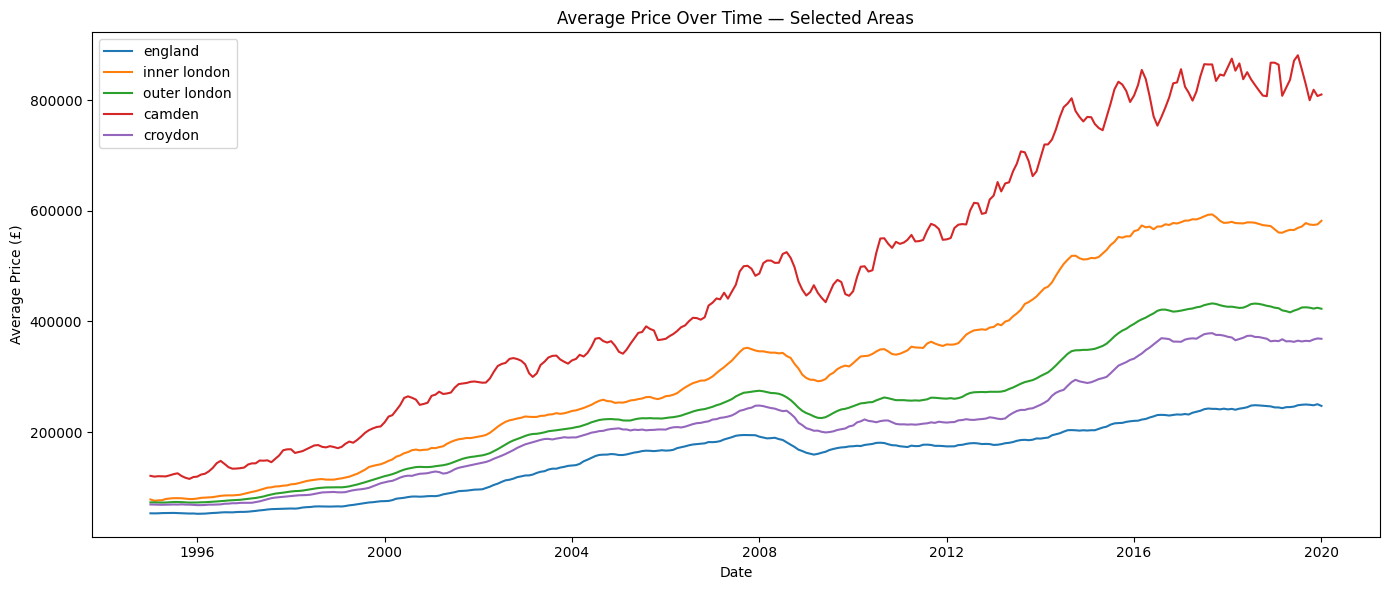

In [69]:
# Compare price trends across a few major areas
major_areas = ['england', 'inner london', 'outer london', 'camden', 'croydon']
comparison = data[data['area'].isin(major_areas)]

plt.figure(figsize=(14, 6))
for area in major_areas:
    subset = comparison[comparison['area'] == area].sort_values('date')
    plt.plot(subset['date'], subset['average_price'], label=area)

plt.title("Average Price Over Time — Selected Areas")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Bivariate — Numerical vs Numerical

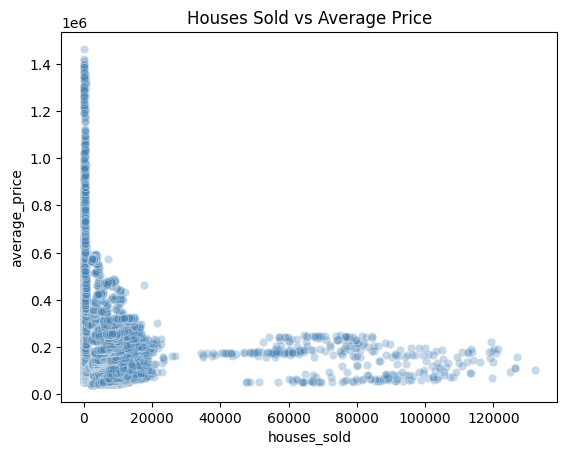

In [70]:
# Houses sold vs Average price — does more demand drive prices up?
sns.scatterplot(x='houses_sold', y='average_price', data=data, alpha=0.3, color='steelblue')
plt.title("Houses Sold vs Average Price")
plt.show()

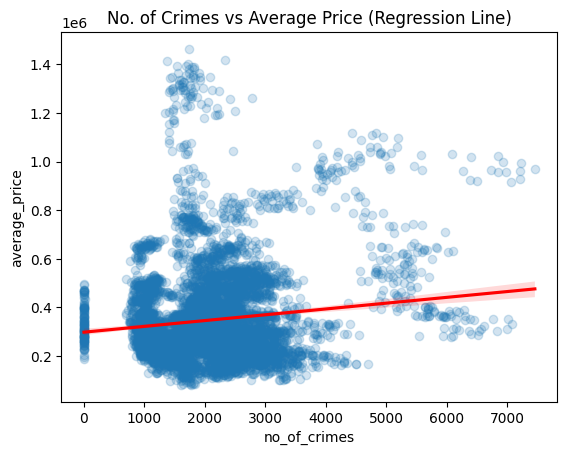

In [71]:
# Crimes vs Average price — is there a relationship?
sns.regplot(x='no_of_crimes', y='average_price', data=data,
            scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title("No. of Crimes vs Average Price (Regression Line)")
plt.show()

### 7.4 Bivariate — Numerical vs Categorical

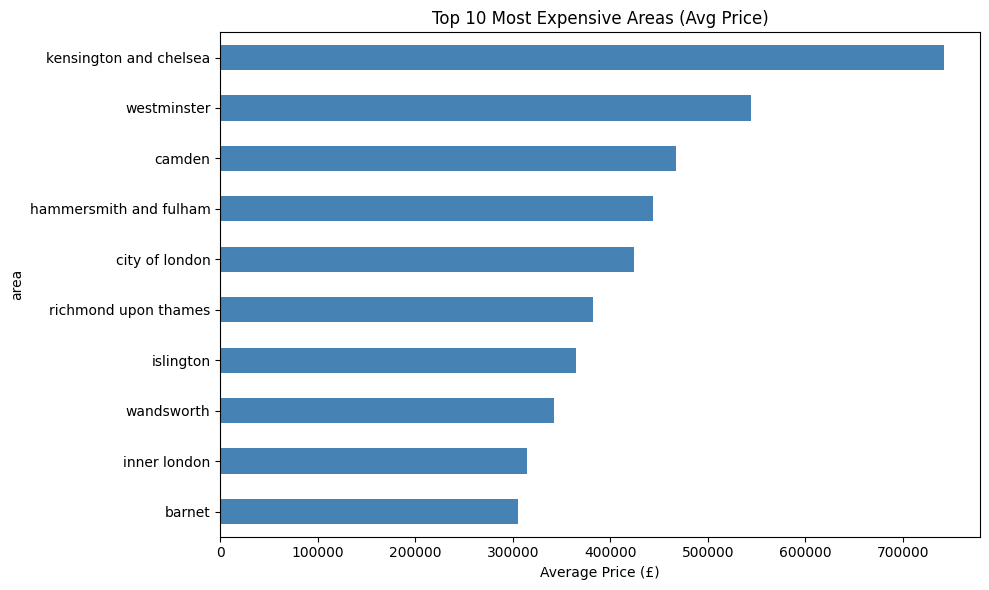

In [72]:
# Average price by area (Top 10 most expensive areas, by mean price)
top10_expensive = data.groupby('area')['average_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10_expensive.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Most Expensive Areas (Avg Price)")
plt.xlabel("Average Price (£)")
plt.tight_layout()
plt.show()

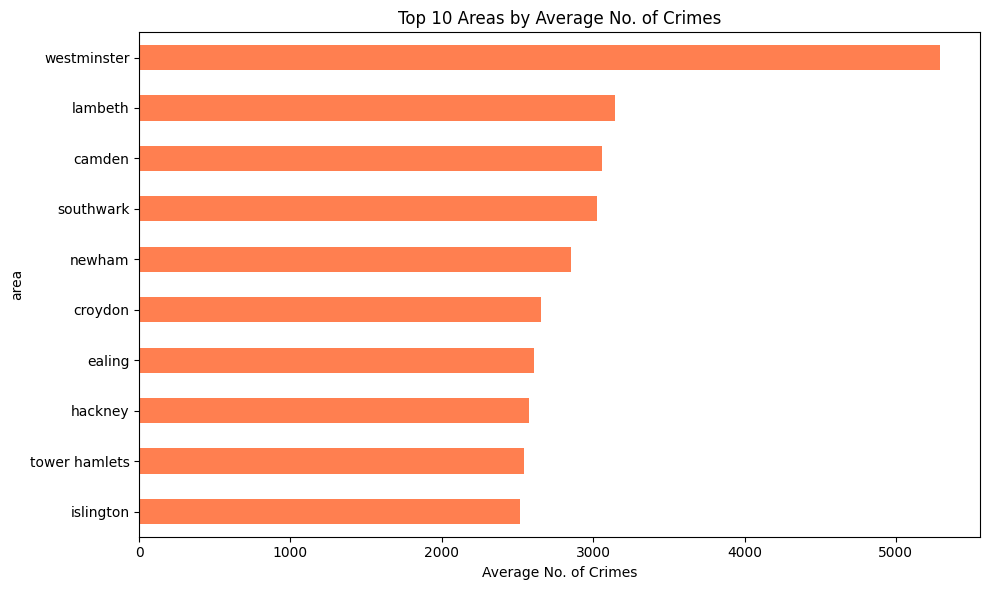

In [73]:
# Average crimes by area (Top 10 highest-crime areas, by mean)
top10_crime = data.groupby('area')['no_of_crimes'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10_crime.sort_values().plot(kind='barh', color='coral')
plt.title("Top 10 Areas by Average No. of Crimes")
plt.xlabel("Average No. of Crimes")
plt.tight_layout()
plt.show()

### 7.5 Correlation Heatmap

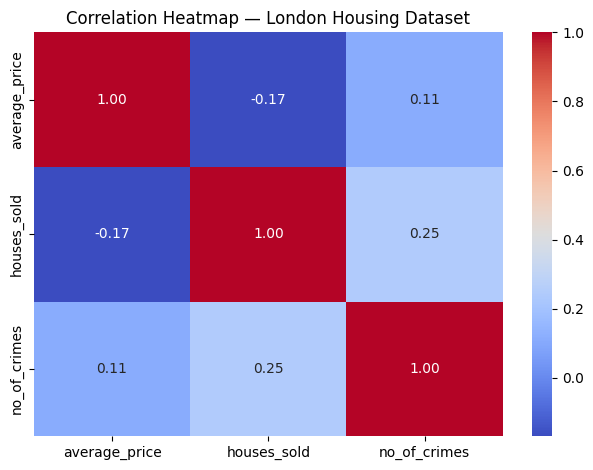

In [74]:
# Heatmap of correlations between numerical variables
sns.heatmap(data[['average_price', 'houses_sold', 'no_of_crimes']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — London Housing Dataset")
plt.tight_layout()
plt.show()

### 7.6 Pairplot

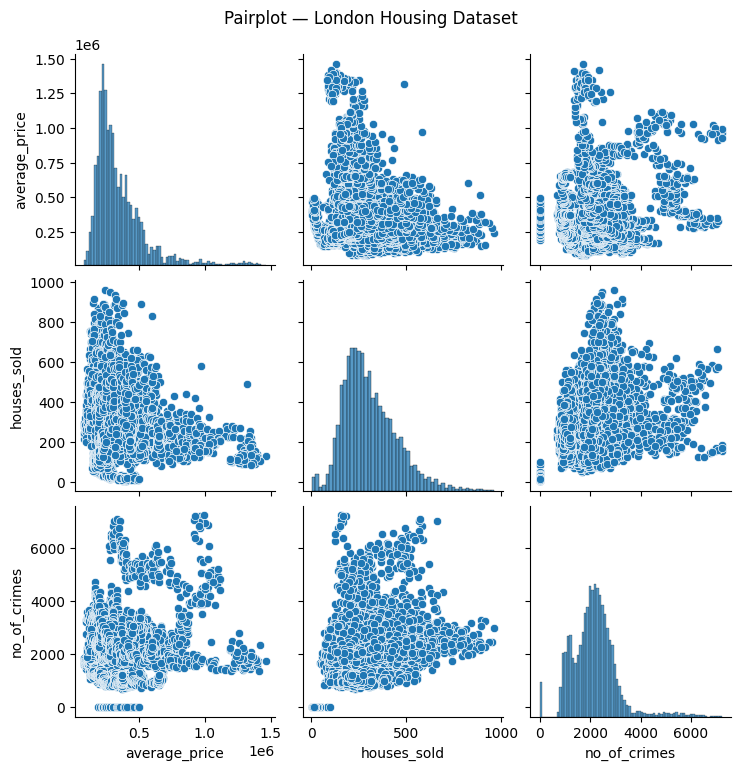

In [75]:
# Pairplot of the core numerical variables
sns.pairplot(data[['average_price', 'houses_sold', 'no_of_crimes']].dropna())
plt.suptitle("Pairplot — London Housing Dataset", y=1.02)
plt.show()

## 8. Key Insights

After analyzing **13,549 monthly housing records across 45 London areas (1995–2019)**:

1. **England's average house price grew dramatically over the 24-year period**  
   The time series shows a clear long-term upward trend, with a noticeable dip around 2008–2009 (the global financial crisis) before resuming growth.

2. **Crime data has a different collection start date than price data**  
   `no_of_crimes` is missing for ~6,110 rows, almost entirely in the earlier years — confirming this metric started being tracked later than housing prices.

3. **Houses sold and average price show only a weak relationship**  
   The scatter plot reveals no strong linear pattern — sales volume is not a reliable predictor of price level on its own.

4. **City of London and Inner London areas dominate the most expensive areas list**  
   The Top 10 most expensive areas analysis is dominated by central London boroughs, consistent with real-world London property market knowledge.

5. **Zero-crime months were heavily concentrated in early years**  
   Most records with `no_of_crimes == 0` come from areas/years where crime tracking had just begun, rather than genuine crime-free months.

6. **Affordable housing (under £100,000) is almost entirely a 1990s phenomenon**  
   The vast majority of records with average_price below £100,000 come from the earliest years in the dataset — by the 2010s, virtually no area remained under this threshold.
